In [5]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sqlite3

In [6]:
# 1. import Database / Data

In [7]:
conn = sqlite3 .connect('customer_churn.db')

sql_query = """
            Select name
            from sqlite_master
            WHERE type = 'table'
            
"""

tables = pd.read_sql(sql_query, conn)

#Create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [8]:
#print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    #Get Column Information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("columns: ")
    print(columns['name'].tolist())

#Close Connection
conn.close()


Table Name: db_customer
columns: 
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
columns: 
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
columns: 
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [9]:
# 2. Data Cleaning

In [10]:
# df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [11]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [12]:
# A. Rename column - name
# B. Drop columns - interest , pincode
# C. Change data type - dob
# D. Data Standardization - gender
# E. Fix missing Values - Country

In [13]:
# A. Rename column - name
df_db_customer.rename(columns = {'name':'customer_name'}, inplace = True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [14]:
# B. Drop columns - interest , pincode

#df_db_customer.drop(df_db_customer.columns[-2: ], axis=1)
#df_db_customer.drop(df_db_customer.columns[6: ], axis=1)

df_db_customer.drop(columns = ['interests' , 'pincode'], inplace =True)

In [15]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [16]:
# C. Change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [17]:
# D. Data Standardization - gender

#df_db_customer['gender'].unique()

df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' :'Female'})

In [18]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [19]:
# E. Fix missing Values - Country

#df_db_customer['country'].isna()
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [20]:
#df_db_customer[['country', 'state']]

#Country And State - Unique Value Pair

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [21]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [22]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [23]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [24]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [25]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [26]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [27]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [28]:
df_db_support.drop(columns=['col_1','comment'], inplace=True)

In [29]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [30]:
# 3. Feature Engineering and Data Analysis

In [31]:
#Create a new column using existing column - churn_flag

df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [32]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [33]:
#First Fix Support table duplicates then merge
df = (df_db_subscription
            .merge(df_db_customer , on = 'customerid', how = 'left')
            .merge(df_db_support , on = 'customerid', how = 'left'))

In [34]:
df_db_subscription.shape

(21, 12)

In [35]:
df.shape

(23, 20)

In [36]:
df_db_subscription['customerid'].nunique()

21

In [37]:
df_db_customer['customerid'].nunique()

21

In [38]:
df_db_support['customerid'].nunique()

7

In [39]:
df_db_support['customerid'].size

9

In [40]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [41]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [42]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [43]:
df_db_support['customerid'].size

7

In [44]:
#Merge DataFrame
df = (df_db_subscription
            .merge(df_db_customer , on = 'customerid', how = 'left')
            .merge(df_db_support , on = 'customerid', how = 'left'))

In [45]:
df.shape

(21, 21)

In [46]:
df.to_csv('exported_churn_data.csv',index=False)

In [47]:
#Data Analysis

In [48]:
# 1. Churn Rate

In [49]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [52]:
churn_rate = df['churn_flag'].mean()*100
print('Churn Rate : ', round(churn_rate,2),"%")

Chuen Rate :  28.57 %


In [53]:
# 2. Retention Rate

In [54]:
retention_rate = 100 - churn_rate
print('Retention Rate : ', round(retention_rate,2),"%")

Retention Rate :  71.43 %


In [57]:
# 3. Churn by Plan Type

In [62]:
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [66]:
# 5. ARPU - Avg Revenue per User
arpu = df['monthly_charges'].mean()
print('ARPU = ',round(arpu,2))

ARPU =  18.85


In [75]:
# 6. Avg Customer Tenure
#count o days users has used our service : cancellation date else current date

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ",round(avg_tenure),0)

Avg Tenure (Days) =  1510 0


In [ ]:
# Homework - calculate customer age

In [79]:
# 7. Revenue at risk - revenue lost from churned users

revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk(Rs 'K') = ", revenue_at_risk)

Revenue at Risk(Rs 'K') =  73.94


In [81]:
# 8. Escalation Rate

escalation_rate = (df['escalations'] =='Y').mean()*100
print('escalation_rate = ', escalation_rate)

escalation_rate =  19.047619047619047


In [84]:
# 9. Avg Complaint per User

avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaint per User = ",round(avg_complaints, 2))

Avg Complaint per User =  0.43


In [93]:
# 10. Correlation Escalation VS Churn

df['escalations'] = np.where(df['escalations'] == 'Y', 1 , 0) # encoding str to int type

corr_df = df[['escalations', 'churn_flag']].dropna() 

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escalation VS churn is = ", round(correlation, 2))

Correlation between escalation VS churn is =  0.77


In [95]:
# 11. create a column using a existing column - Churn risk

conditions =[
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70),
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unknown')

In [98]:
df[['churn_risk','churn_score']].tail()

,churn_risk,churn_score
16,med,62
17,low,27
18,unknown,99
19,low,7
20,low,47


In [ ]:
## 4. Visualization Using Matplotlib


In [99]:
df_visual = df.copy()

In [101]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

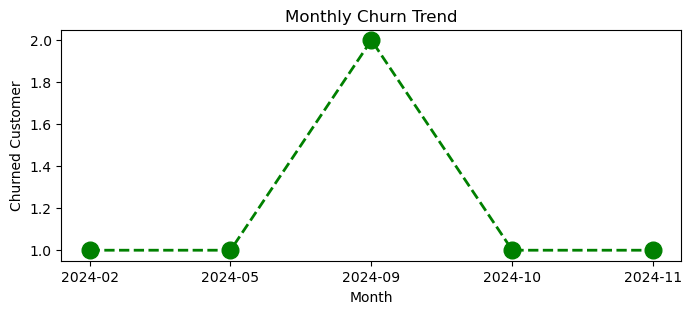

In [115]:
# 4.1 Monthly Churn trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

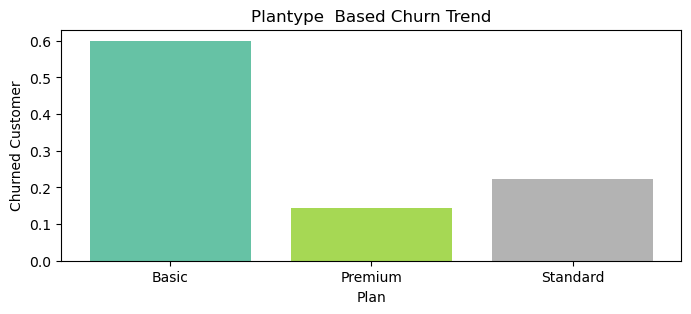

In [126]:
# 4.2 Churn by Plan type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

#colors = ['lightblue','blue','darkblue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(8,3))

plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Plantype  Based Churn Trend')
plt.xlabel('Plan')
plt.ylabel('Churned Customers')
plt.show()

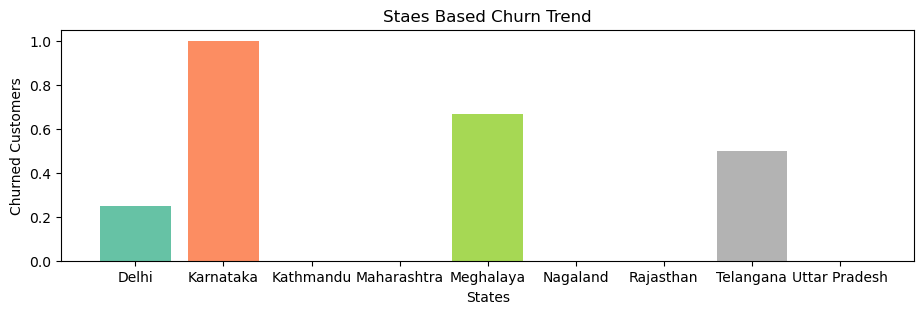

In [130]:
# 4.3 Churn by States

churn_state = df_visual.groupby('state')['churn_flag'].mean()

#colors = ['lightblue','blue','darkblue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_state)))

plt.figure(figsize=(11,3))

plt.bar(churn_state.index, churn_state.values, color = colors)

plt.title('Staes Based Churn Trend')
plt.xlabel('States')
plt.ylabel('Churned Customers')
plt.show()


In [ ]:
# Visualization using seaborn

In [132]:
#Emcoding - Convert str to numeric so that we can find correlation between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [133]:
df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,unknown,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,unknown,1


In [135]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,0,0
1,1,0,91,1,2,1
2,0,1,34,0,0,0
3,1,0,8,0,0,0
4,2,1,88,1,2,1


In [140]:
import warnings
warnings.filterwarnings("ignore")

In [141]:
## Initial categorical encoding
#method of encoding = as numbers are not assigned based on priority

df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

categorical_cols = ['plan_type','contract_type','churn_risk']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

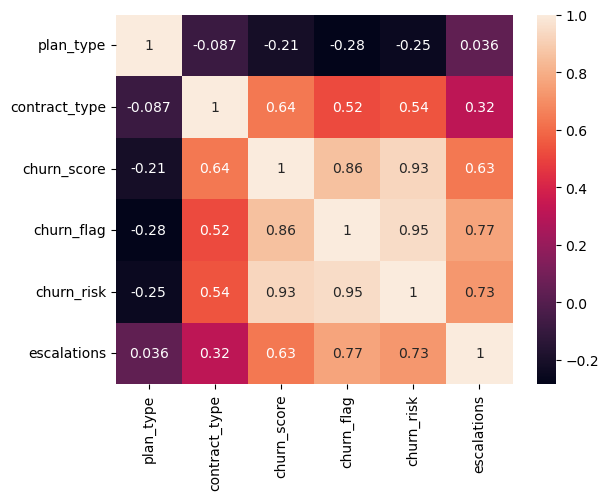

In [142]:
#Heatmap(correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

In [148]:
#df_visual['plan_type'].unique()
#df_visual['contract_type'].unique()
#df_visual['churn_risk'].unique()

#df_visual['churn_risk'] = df_visual['churn_risk'].replace('unknown','high')
df_visual['churn_risk'].head()

0     low
1    high
2     low
3     low
4    high
Name: churn_risk, dtype: object

In [150]:
#correct method of encoding = based on priority

df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

order_mapping = {
    'plan_type' : ['Basic','standard','premium'],
    'contract_type' : ['Monthly','Annual'],
    'churn_risk' : ['low','med','high']
}

for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'),categories=order, ordered=True).codes

In [154]:
df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [151]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,-1,1,12,0,0,0
1,-1,1,91,1,2,1
2,0,0,34,0,0,0
3,-1,1,8,0,0,0
4,-1,0,88,1,2,1


<Axes: >

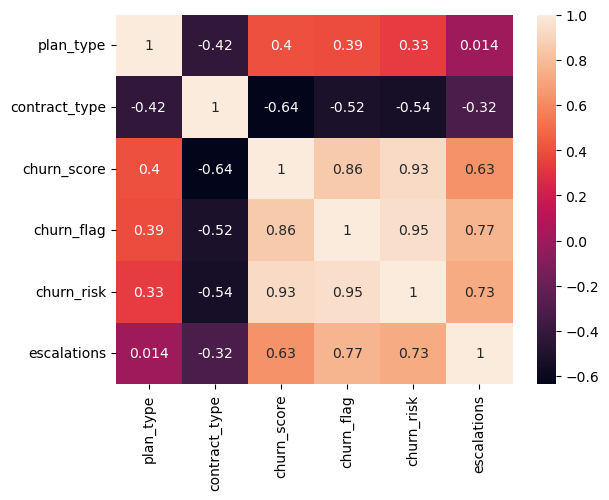

In [155]:
#Heatmap(correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

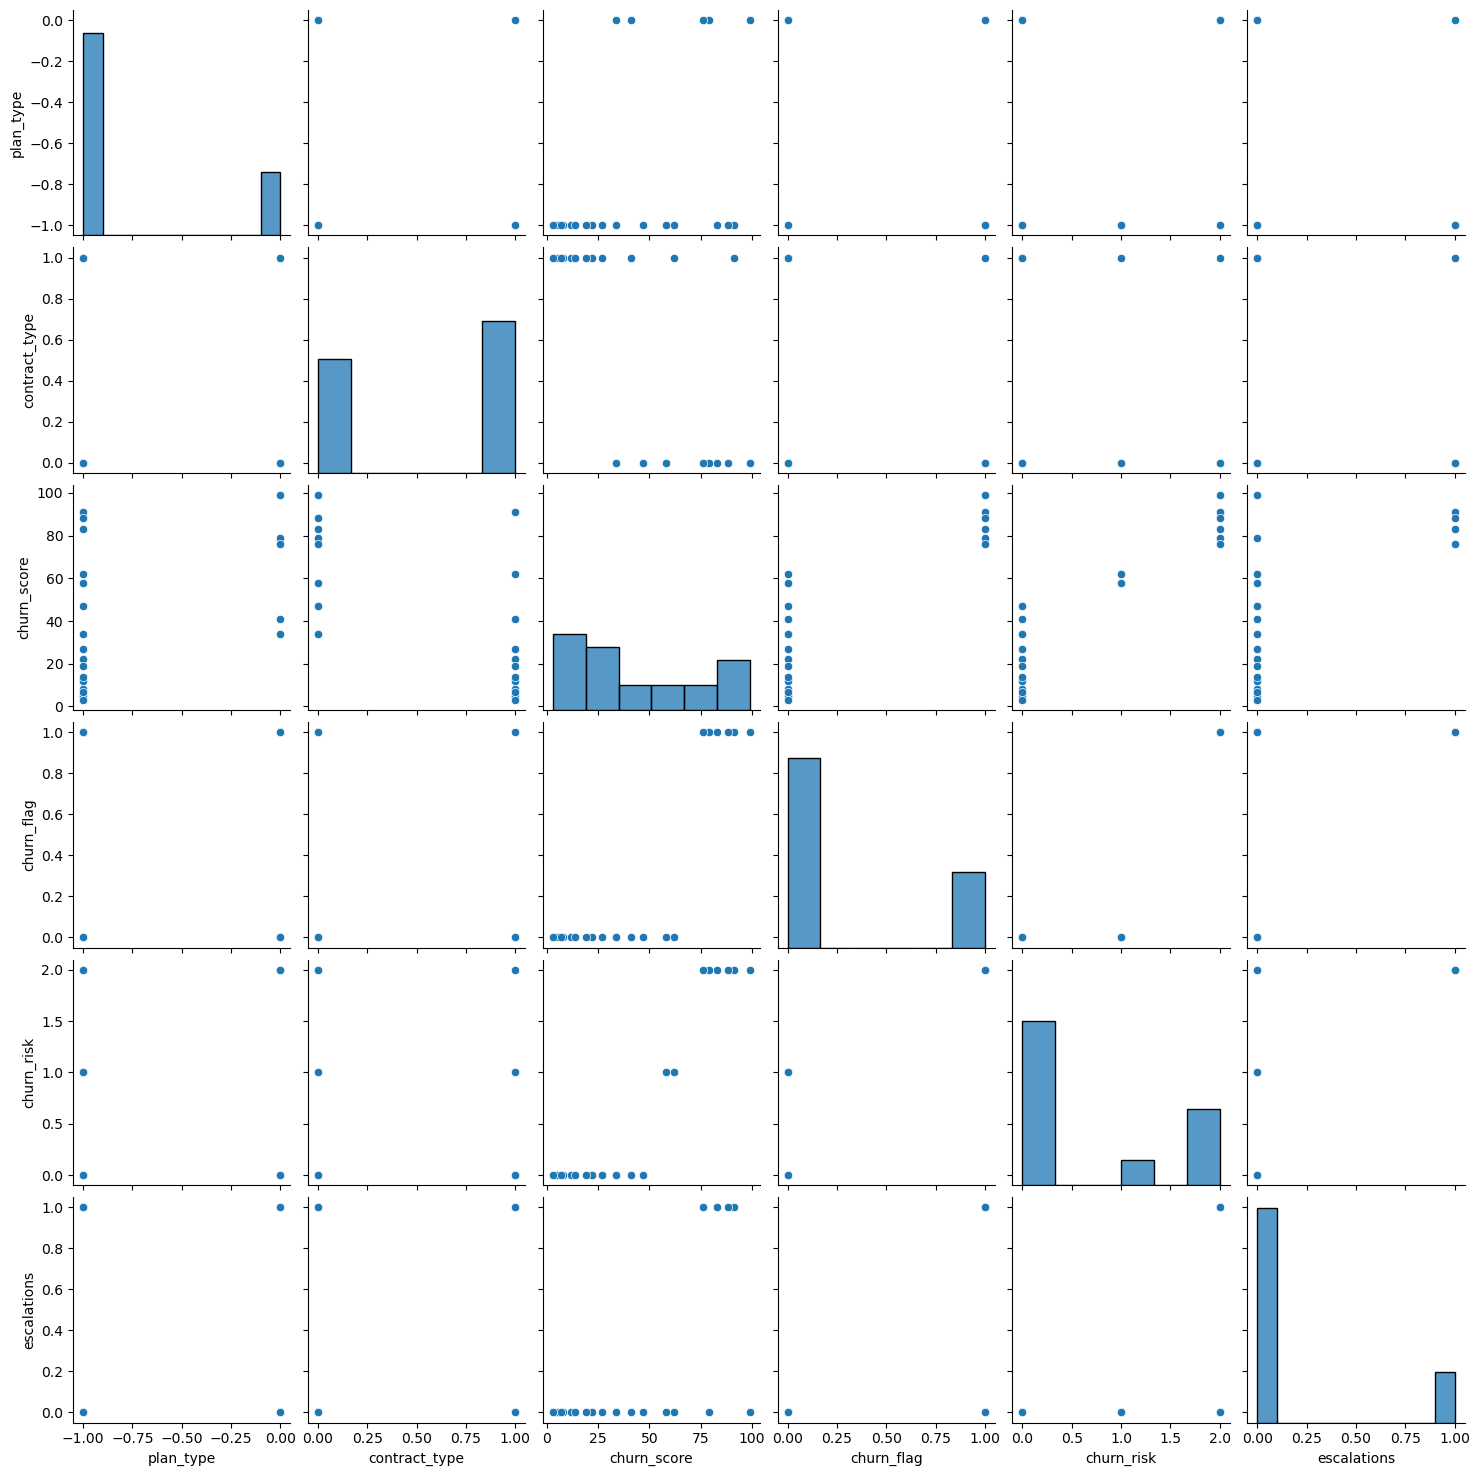

In [156]:
# Pairplot - relationship in dataset
sns.pairplot(df_encoded)

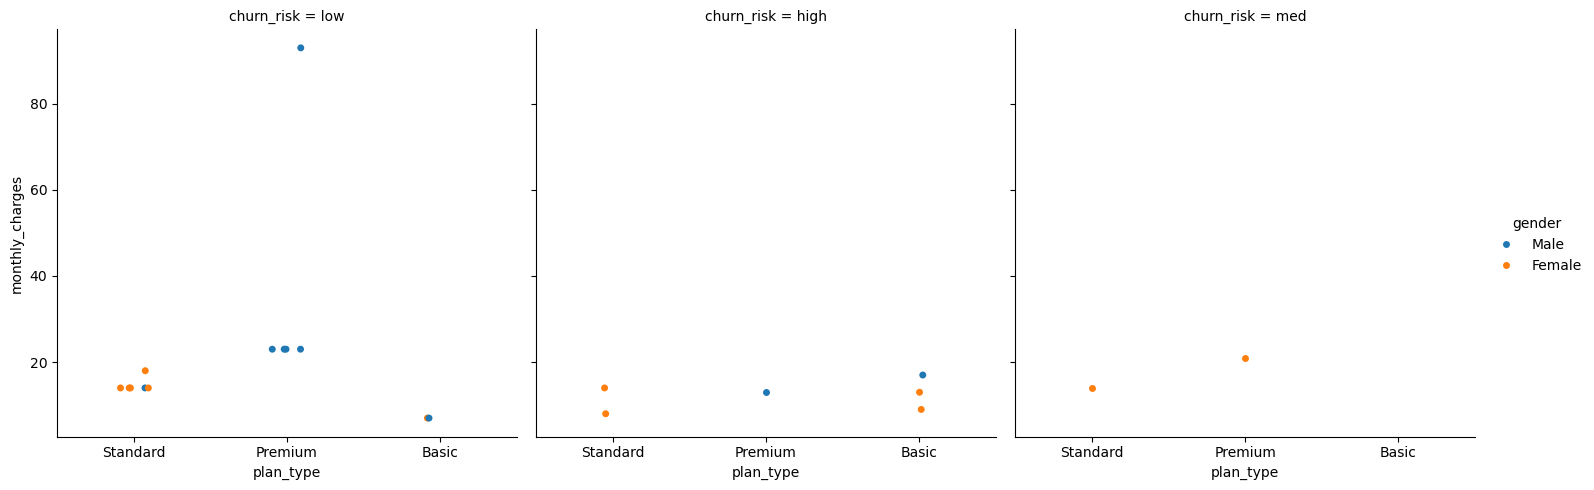

In [157]:
# categorical pl0t/ Facegrid plot - Multi-dimension comparison

sns.catplot(data=df_visual,
            x='plan_type',
           y='monthly_charges',
           hue='gender',
           col='churn_risk')

In [158]:
#Pivot Table

In [160]:
pd.pivot_table(
    df_visual,
    values ='churn_flag',
    index ='plan_type',
    aggfunc = 'mean',
)

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [162]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [164]:
pd.pivot_table(
    df_visual,
    index ='plan_type',
    values =['monthly_charges','customerid','churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
